In [18]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Functions

In [5]:
def plot_3d(x, y, z, xlabel="X", ylabel="Y", zlabel="Z", title=None):
    fig = plt.figure(figsize=(6, 8), dpi=150)
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(x, y, z, s=30, alpha=0.8)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_zlabel(zlabel)

    if title:
        ax.set_title(title)

    plt.tight_layout()
    plt.show()

    return fig, ax

def pca_from_dataframes(
    df_list,
    labels,
    columns,
    figsize=(6, 5),
    dpi=150,
    show=True,
):
    """
    PCA from list of dataframes.

    Parameters
    ----------
    df_list : list[pd.DataFrame]
        One dataframe per sample.

    labels : list[str]
        Sample names.

    columns : list[str]
        Numerical features for PCA.

    Returns
    -------
    pca_df
    pca
    """

    dfs = []

    for df, label in zip(df_list, labels):

        tmp = df[columns].copy()
        tmp["sample"] = label

        dfs.append(tmp)

    data = pd.concat(dfs, ignore_index=True)

    X = data[columns]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=2)

    pcs = pca.fit_transform(X_scaled)

    pca_df = pd.DataFrame(
        pcs,
        columns=["PC1", "PC2"]
    )

    pca_df["sample"] = data["sample"].values

    fig, ax = plt.subplots(
        figsize=figsize,
        dpi=dpi
    )

    for label in labels:

        subset = pca_df[
            pca_df["sample"] == label
        ]

        ax.scatter(
            subset["PC1"],
            subset["PC2"],
            alpha=0.6,
            label=label,
            s=20
        )

    ax.set_xlabel(
        f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"
    )

    ax.set_ylabel(
        f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
    )

    ax.legend(frameon=False)

    plt.tight_layout()

    if show:
        plt.show()

    return pca_df, pca

# Load data

In [2]:
data = [
        {'name': 'WT', 'path': "/mnt/c/users/elopatukhin/Desktop/020226/WT/foci_aggregation.csv"},
        {'name': 'MGS1', 'path': "/mnt/c/users/elopatukhin/Desktop/020226/MGS1/foci_aggregation.csv"},
        {'name': 'MGS2', 'path': "/mnt/c/users/elopatukhin/Desktop/020226/MGS2/foci_aggregation.csv"},
        {'name':'MGS3', 'path': "/mnt/c/users/elopatukhin/Desktop/020226/MGS3/foci_aggregation.csv"},
        {'name':'MGS4', 'path': "/mnt/c/users/elopatukhin/Desktop/020226/MGS4/foci_aggregation.csv"},
        {'name':'MGS5', 'path': "/mnt/c/users/elopatukhin/Desktop/020226/MGS5/foci_aggregation.csv"},
    ]

labels = [df['name'] for df in data]
print(labels)

['WT', 'MGS1', 'MGS2', 'MGS3', 'MGS4', 'MGS5']


In [3]:
dfs = []
for item in data:
        p = item["path"]
        df = pd.read_csv(p)
        dfs.append(df)

N_files = len(dfs)
print(f"Loaded {N_files} dataframes.")

Loaded 6 dataframes.


In [4]:
# Names of columns
print(dfs[0].columns)

Index(['filname', 'n_foci', 'sigma_nm_mean', 'sigma_nm_sd',
       'intensity_photon_mean', 'intensity_photon_sd', 'sigma_pixel_mean',
       'sigma_pixel_sd', 'foci_MFI_mean', 'foci_MFI_sd'],
      dtype='str')


# PCA

## Graphs

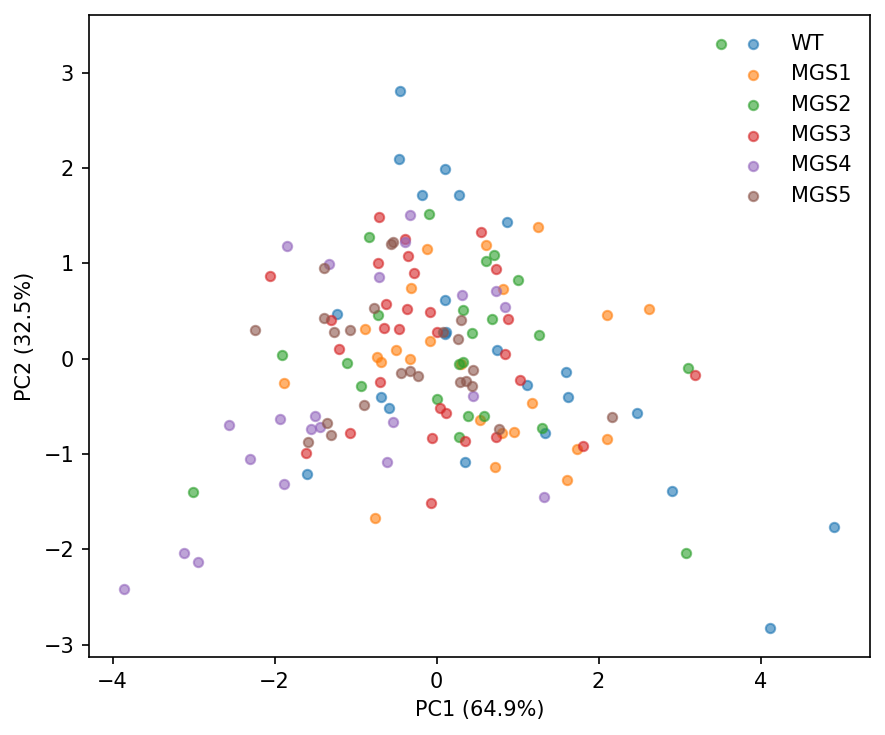

In [6]:
pca_df, pca = pca_from_dataframes(
    df_list=dfs,
    labels=labels,
    columns=[
        "sigma_nm_mean",
        "foci_MFI_mean",
        "n_foci"
    ]
)

In [10]:
# How much of the total variation in your data is explained by each principal component
print(pca.explained_variance_ratio_)

[0.64865022 0.32540055]


## Explanation of each component

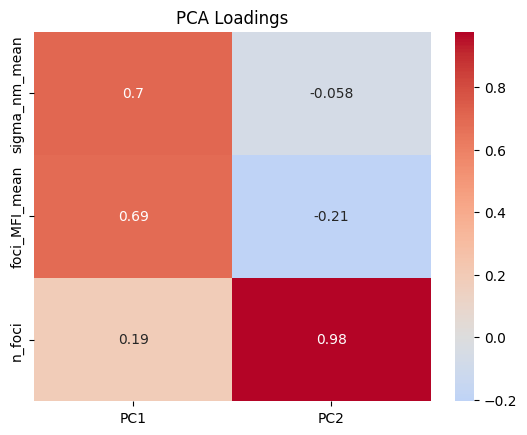

In [20]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=[
        "sigma_nm_mean",
        "foci_MFI_mean",
        "n_foci"
    ],
    columns=["PC1", "PC2"]
)

sns.heatmap(
    loadings,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("PCA Loadings")
plt.show()

In [ ]:
wt_pc1 = pca_df.loc[pca_df["sample"] == "WT", "PC1"]
mgs3_pc1 = pca_df.loc[pca_df["sample"] == "MGS3", "PC1"]

from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(wt_pc1, mgs3_pc1)

print(p)

In [ ]:
wt_pc1 = pca_df.loc[pca_df["sample"] == "WT", "PC2"]
mgs3_pc1 = pca_df.loc[pca_df["sample"] == "MGS3", "PC2"]

from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(wt_pc1, mgs3_pc1)

print(p)

In [ ]:


print(loadings)

                    PC1       PC2
sigma_nm_mean  0.701442 -0.057850
foci_MFI_mean  0.688054 -0.205012
n_foci         0.185905  0.977048


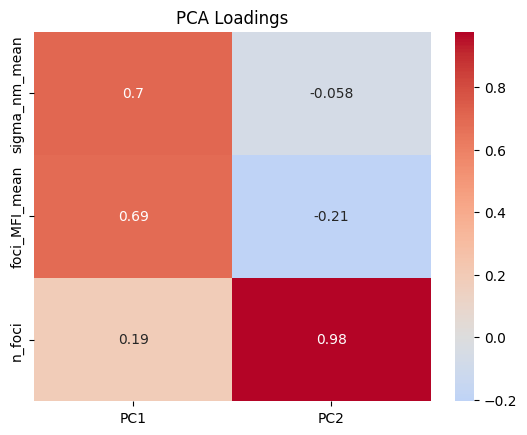

In [14]:
pca_df.groupby("sample")[["PC1","PC2"]].mean()

,PC1,PC2
sample,,
MGS1,0.460397,-0.087503
MGS2,0.386942,0.158953
MGS3,-0.081959,0.128945
MGS4,-1.144954,-0.374586
MGS5,-0.426505,0.024071
WT,0.762945,0.090437
